# Compare LLMs to baseline in Dragon Hunt use case

Baselines: rule-based MT

LLMs: gpt-4o-mini-2024-07-18, o3-mini-2025-01-31

In [1]:
%cd ..
%pwd  # should be "llm-adaptation"

c:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


'c:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set(rc={'text.usetex' : True})

## Load online data

In [3]:
summary = pd.read_csv(Path("results/dragon/summary.csv"))

In [4]:
palette = {
    "baseline": "tab:gray",
    "gpt4omini": "tab:red",
    "o3mini": "tab:blue",
}

In [5]:
llm_names = {
    "baseline": "Baseline",
    "gpt4omini": "GPT-4o mini",
    "o3mini": "OpenAI o3-mini",
}
summary['LLM'] = summary['llm'].map(llm_names)
palette_LLM = {v: palette[k] for k, v in llm_names.items()}

In [6]:
params = {
    "Default": "Zero\nstrategy",
    "strategy": "High-level\nstrategy",
    "Rule-based MT": "Rule-based",
}
summary['params'] = summary['params'].replace(params)

In [7]:
summary['Final Dragon HP'] = summary['hp'].where(summary['hp'] > 0, other=0)

In [8]:
summary

,llm,params,steps,hp,LLM,Final Dragon HP
0,baseline,Rule-based,11,-7,Baseline,0
1,baseline,Rule-based,9,-4,Baseline,0
2,baseline,Rule-based,16,-7,Baseline,0
3,baseline,Rule-based,12,-1,Baseline,0
4,baseline,Rule-based,9,-4,Baseline,0
5,baseline,Rule-based,13,-1,Baseline,0
6,baseline,Rule-based,15,-10,Baseline,0
7,baseline,Rule-based,14,-1,Baseline,0
8,baseline,Rule-based,10,-4,Baseline,0
9,baseline,Rule-based,11,-4,Baseline,0


## Plot

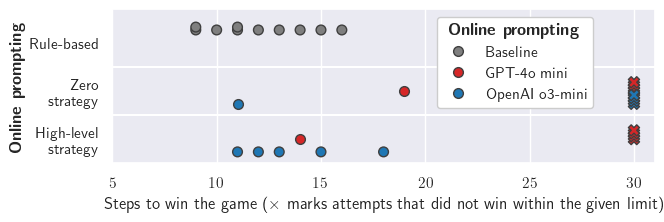

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))
# fig, ax = plt.subplots(figsize=(7, 2))
plot_kwargs = {
    "dodge": True,
    "jitter": False,
    "linewidth": 1,
}
wins = summary[summary["steps"] != 30]
loses = summary[summary["steps"] == 30]

baselines = ["Baseline"]
llms = ["GPT-4o mini", "OpenAI o3-mini"]

# sns.stripplot(x="steps", y="params", hue="LLM", data=wins[wins["LLM"].isin(baselines)], ax=ax, palette={key: palette_LLM[key] for key in baselines}, hue_order=baselines, **plot_kwargs)
# sns.stripplot(x="steps", y="params", hue="LLM", data=wins[wins["LLM"].isin(llms)], ax=ax, palette={key: palette_LLM[key] for key in llms}, hue_order=llms, **plot_kwargs)
sns.stripplot(x="steps", y="params", hue="LLM", data=wins, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), **plot_kwargs, size=7)
sns.stripplot(x="steps", y="params", hue="LLM", data=loses, marker="X", legend=False, ax=ax, palette=palette_LLM, hue_order=palette_LLM.keys(), **plot_kwargs, size=8)

# add custom jitter
for dots in ax.collections:
    xs, ys = dots.get_offsets().T
    jitter_ys = ys[:]
    for i, x in enumerate(xs):
        count = np.sum(xs[:i] == x)
        jitter_ys[i] = ys[i] + -0.06 * count
    dots.set_offsets(np.column_stack((xs, jitter_ys)))

# add lines separating params
for y in range(0, 2):
    # ax.plot([0, 31], [y + 0.5, y + 0.5], linestyle=(0, (5, 5)), c='lightgray')
    ax.plot([0, 31], [y + 0.5, y + 0.5], c='white')

plt.xlim(5, 31)
# plt.xlim(0, 31)
plt.ylim(2.5, -0.7)

ax.set_ylabel("\\textbf{Online prompting}")
ax.legend(facecolor='white', loc="upper right", bbox_to_anchor=(0, 0, 0.9, 1), title="\\textbf{Online prompting}", framealpha=1)
# ax.legend(facecolor='white', loc="upper right", bbox_to_anchor=(0, 0, 0.93, 1), title="\\textbf{Online prompting}", framealpha=1)

plt.xlabel("Steps to win the game (× marks attempts that did not win within the given limit)")
plt.savefig("results/dragon/dragon_plot.pdf", bbox_inches="tight")
plt.show()